In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("loan_approval_data.csv")

# Checking data

In [3]:
df.info()
df.isnull().sum()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handling missing values / data cleaning

In [4]:
numerical_cols=df.select_dtypes(include=["number"]).columns
categorical_cols=df.select_dtypes(include=["object"]).columns #we get columns names

from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols]) 

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

# here we are using simpleimputer fill misssing values in cols with strategy we provide(mean for numericl and mode for categorical)
df.isnull().mean()


Applicant_ID          0.0
Applicant_Income      0.0
Coapplicant_Income    0.0
Employment_Status     0.0
Age                   0.0
Marital_Status        0.0
Dependents            0.0
Credit_Score          0.0
Existing_Loans        0.0
DTI_Ratio             0.0
Savings               0.0
Collateral_Value      0.0
Loan_Amount           0.0
Loan_Term             0.0
Loan_Purpose          0.0
Property_Area         0.0
Education_Level       0.0
Gender                0.0
Employer_Category     0.0
Loan_Approved         0.0
dtype: float64

# EDA - Exploratory Data Analysis

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

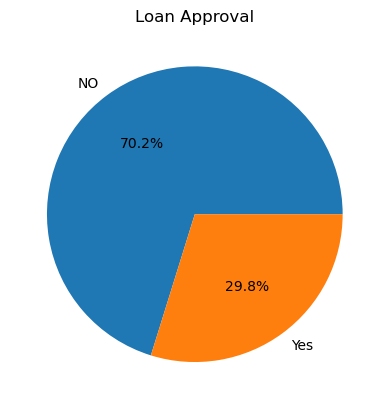

In [5]:

classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["NO","Yes"],autopct="%1.1f%%")
plt.title("Loan Approval")
classes_count

<Axes: xlabel='Gender', ylabel='count'>

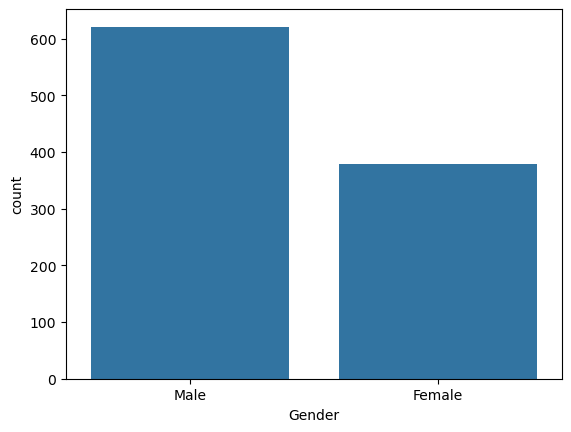

In [6]:
gender_count=df["Gender"].value_counts()
sns.barplot(gender_count)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

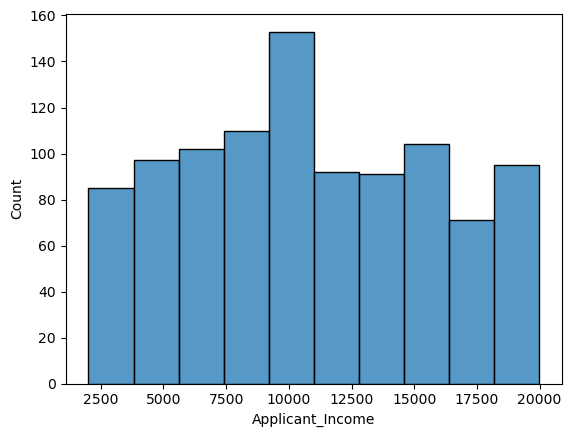

In [7]:
# income analysis
sns.histplot(data=df,x="Applicant_Income",bins=10)

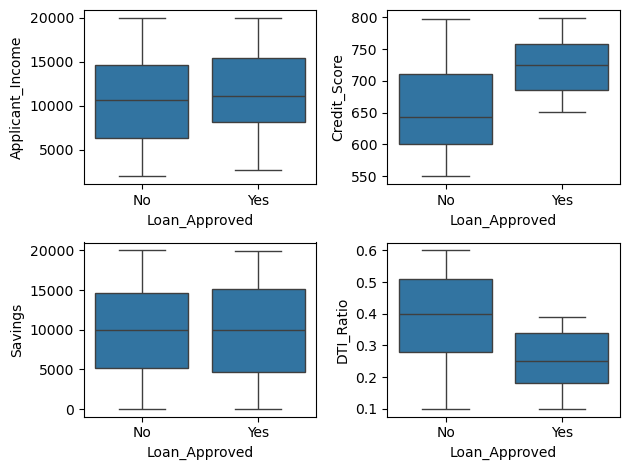

In [8]:
# outliers detection

fig, axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0][0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0][1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1][0],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1][1],data=df,x="Loan_Approved",y="DTI_Ratio")
fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

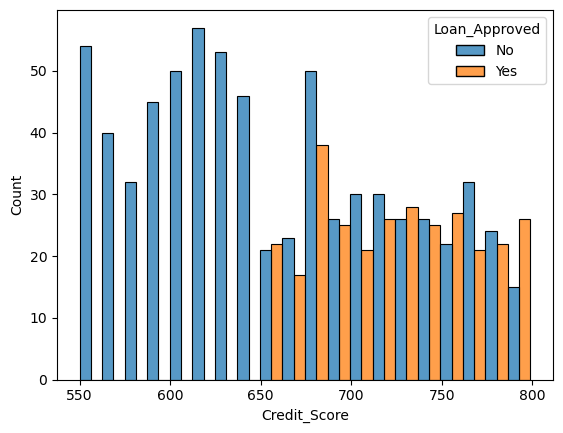

In [9]:
# creditscore and loan approval

sns.histplot(data=df,x="Credit_Score",hue="Loan_Approved",bins=20,multiple="dodge")

In [10]:
df=df.drop("Applicant_ID",axis=1) # removing any unnecessary features(columns)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Feature Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])


#OneHOtEncoder


cols= ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded=ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Corelation

In [16]:
count_vals=df.select_dtypes(include="number")
corr_matrix=count_vals.corr()
count_vals.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

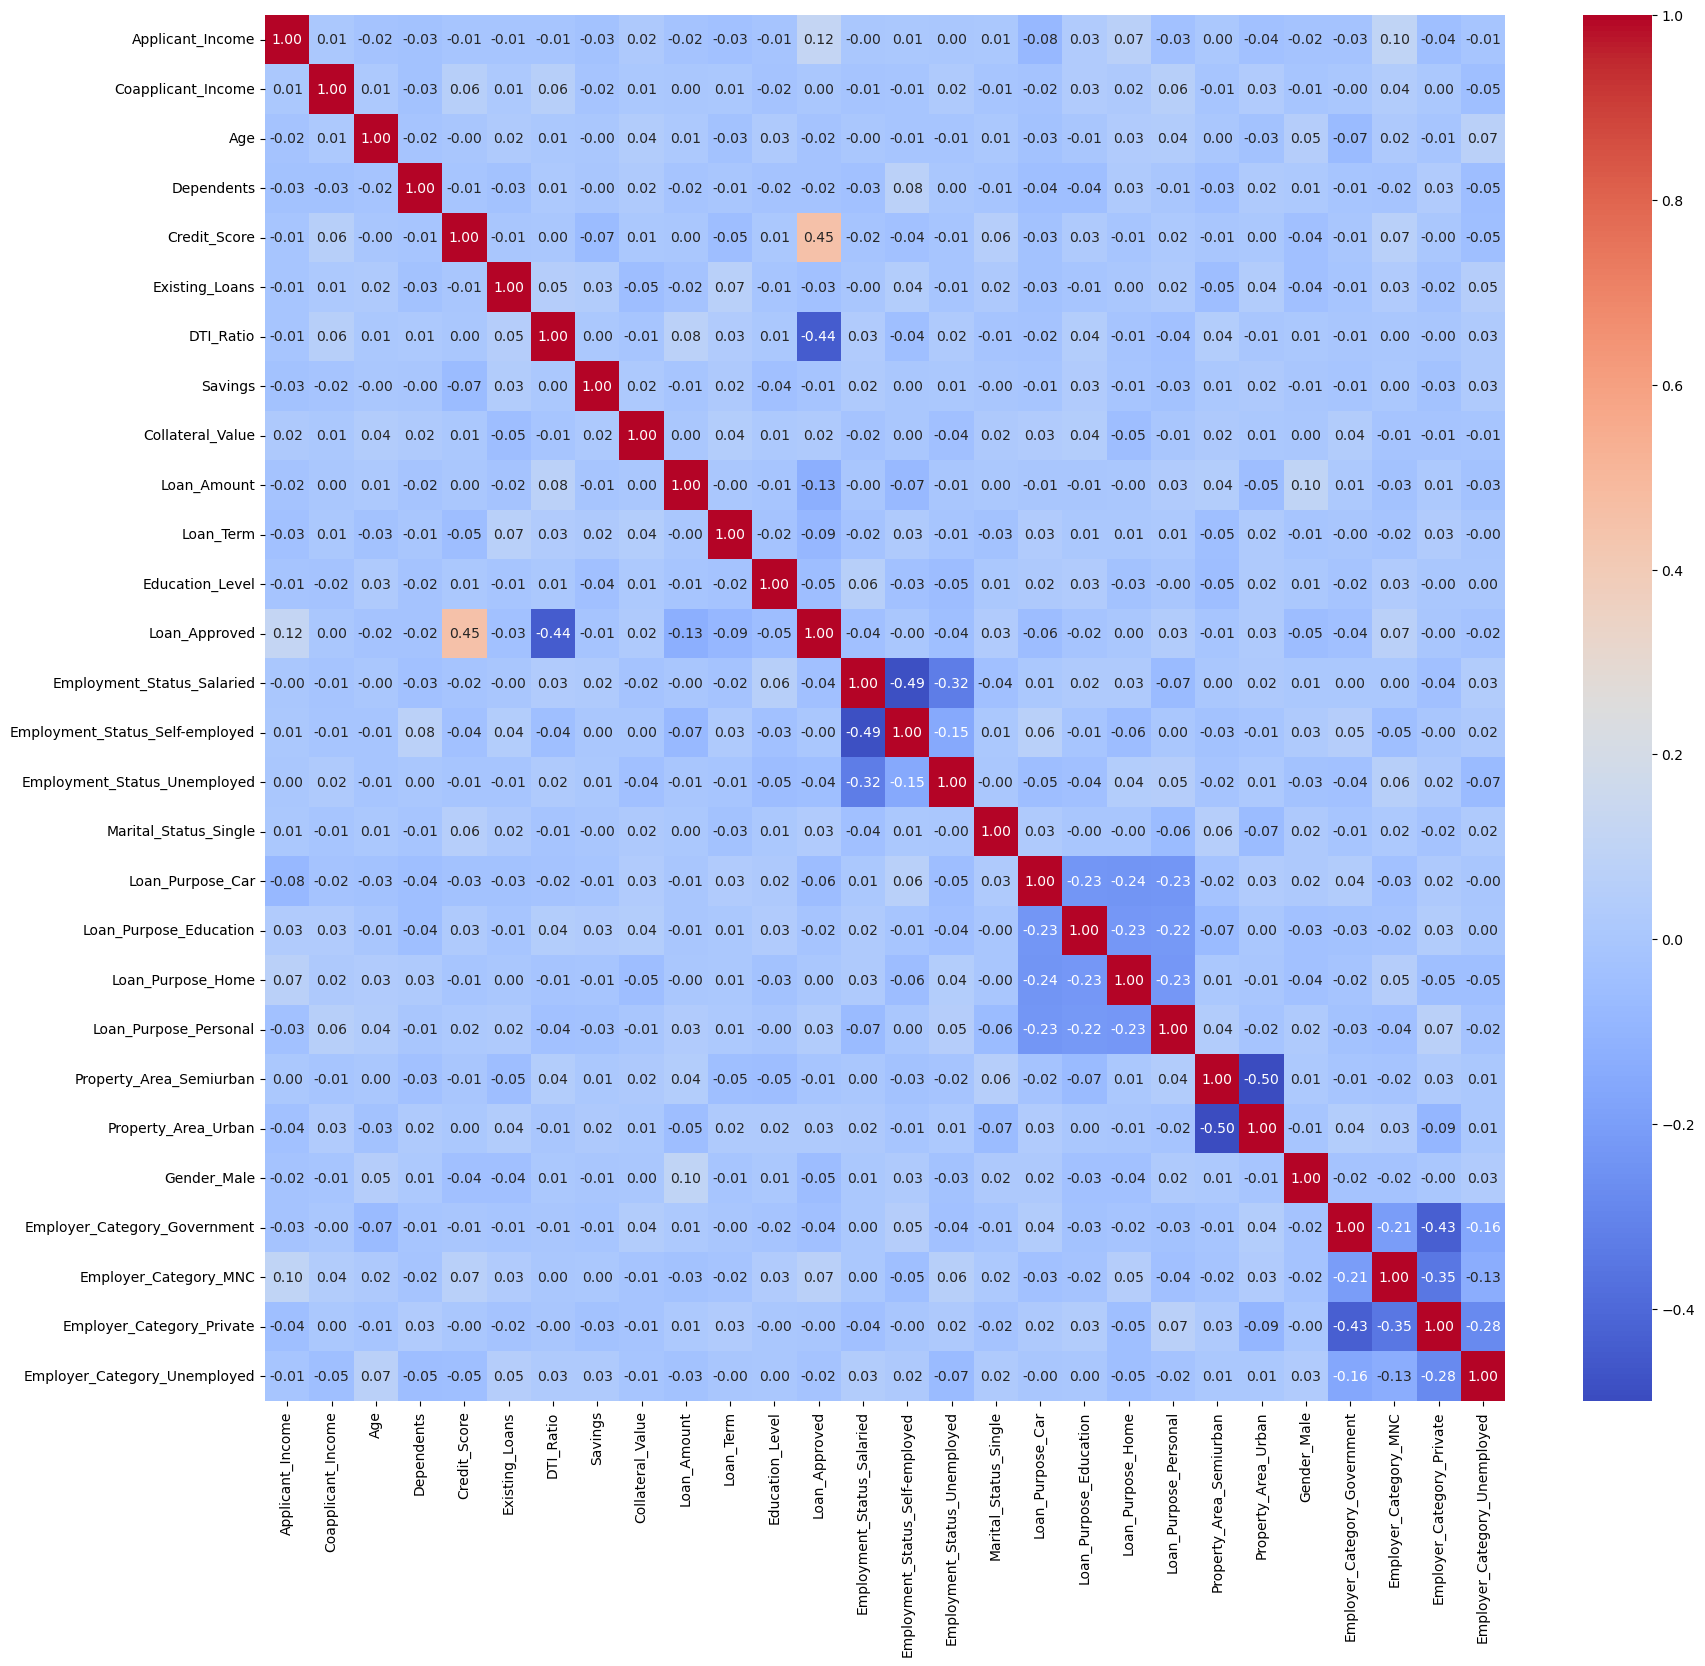

In [21]:
plt.figure(figsize=(20,18))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm")

# Train-Test_split & Feature Scaling

In [23]:
X=df.drop(columns=["Loan_Approved"])
Y=df["Loan_Approved"]

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=26)

In [27]:
# scaling 

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
# X_train_scaled